# Activity: Explore confidence intervals

## Introduction

The Air Quality Index (AQI) is the Environmental Protection Agency's index for reporting air quality. A value close to 0 signals little to no public health concern, while higher values are associated with increased risk to public health. The United States is considering a new federal policy that would create a subsidy for renewable energy in states observing an average AQI of 10 or above. <br>

You've just started your new role as a data analyst in the Strategy division of Ripple Renewable Energy (RRE). **RRE operates in the following U.S. states: `California`, `Florida`, `Michigan`, `Ohio`, `Pennsylvania`, `Texas`.** You've been tasked with constructing an analysis which identifies which of these states are most likely to be affected, should the new federal policy be enacted.

Your manager has requested that you do the following for your analysis:
1. Provide a summary of the mean AQI for the states in which RRE operates.
2. Construct a boxplot visualization for AQI of these states using `seaborn`.
3. Evaluate which state(s) may be most affected by this policy, based on the data and your boxplot visualization.
4. Construct a confidence interval for the RRE state with the highest mean AQI.

## Step 1: Imports

### Import packages

Import `pandas` and `numpy`.

In [1]:
# Import relevant packages
import pandas as pd
import numpy as np


### Load the dataset

The dataset provided gives national Air Quality Index (AQI) measurements by state over time.  `Pandas` is used to import the file `c4_epa_air_quality.csv` as a DataFrame named `aqi`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

*Note: For the purposes of your analysis, you can assume this data is randomly sampled from a larger population.*

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA
aqi = pd.read_csv('c4_epa_air_quality.csv')

## Step 2: Data exploration

### Explore your dataset

Before proceeding to your deliverables, spend some time exploring the `aqi` DataFrame. 

In [3]:
# Display the first 5 rows
aqi.head()

# Get a summary of the DataFrame
aqi.info()

# Get basic statistics of numeric columns
aqi.describe()

# View unique states (optional, helpful later)
aqi["state_name"].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        260 non-null    int64  
 1   date_local        260 non-null    object 
 2   state_name        260 non-null    object 
 3   county_name       260 non-null    object 
 4   city_name         260 non-null    object 
 5   local_site_name   257 non-null    object 
 6   parameter_name    260 non-null    object 
 7   units_of_measure  260 non-null    object 
 8   arithmetic_mean   260 non-null    float64
 9   aqi               260 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 20.4+ KB


array(['Arizona', 'Ohio', 'Wyoming', 'Pennsylvania', 'Iowa', 'Hawaii',
       'Colorado', 'Minnesota', 'Indiana', 'Missouri', 'Connecticut',
       'California', 'Nevada', 'Virginia', 'Rhode Island', 'Texas',
       'Illinois', 'Kansas', 'Maryland', 'New Jersey', 'Massachusetts',
       'Maine', 'Idaho', 'Florida', 'Vermont', 'Tennessee', 'Georgia',
       'South Dakota', 'North Carolina', 'West Virginia', 'Michigan',
       'Nebraska', 'Alabama', 'Washington', 'Kentucky', 'Oklahoma',
       'New York', 'North Dakota', 'Montana', 'Utah', 'Delaware',
       'New Hampshire', 'Louisiana', 'Mississippi', 'New Mexico',
       'Oregon', 'District Of Columbia', 'Arkansas', 'Puerto Rico',
       'South Carolina', 'Alaska', 'Wisconsin'], dtype=object)

**Question:** What time range does this data cover?

The data covers AQI measurements from **[start date]** to **[end date]**. This indicates the range of dates over which air quality was recorded across various states.


**Question:** What are the minimum and maximum AQI values observed in the dataset?

The minimum AQI value observed in the dataset is **[min AQI]**, and the maximum AQI value is **[max AQI]**. These values represent the range of air quality readings captured.


**Question:** Are all states equally represented in the dataset?

No, not all states are equally represented in the dataset. Some states have significantly more AQI records than others, as indicated by the `value_counts()` of the `state_name` column. This suggests varying data availability or monitoring frequency across states.


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about descriptive statisics](https://www.coursera.org/learn/the-power-of-statistics/lecture/jVRS4/measures-of-central-tendency).
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use `pandas` or `numpy` to explore the `aqi` DataFrame.
</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use any of the following functions:
- `pandas`: `describe()`,`value_counts()`,`shape()`
- `numpy`: `unique()`,`mean()`
    
</details>

## Step 3: Statistical tests

### Summarize the mean AQI for RRE states

Start with your first deliverable. Summarize the mean AQI for the states in which RRE operates (California, Florida, Michigan, Ohio, Pennsylvania, and Texas).

In [4]:
# Create a list of RRE states
rre_states = ["California", "Florida", "Michigan", "Ohio", "Pennsylvania", "Texas"]

# Subset the DataFrame to only include RRE states
rre_aqi = aqi[aqi["state_name"].isin(rre_states)]

# Calculate the mean AQI for each RRE state
mean_aqi_by_state = rre_aqi.groupby("state_name")["aqi"].mean().sort_values(ascending=False)

# Display the result
print(mean_aqi_by_state)


state_name
California      12.121212
Michigan         8.111111
Florida          5.500000
Ohio             3.333333
Pennsylvania     2.900000
Texas            2.700000
Name: aqi, dtype: float64


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Subset your DataFrame to only include those states in which RRE operates. 
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Define a list consisting of the states in which RRE operates and use that list to subset your DataFrame. 
    
</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use `pandas` `isin.()` to subset your DataFrame by the list of RRE states.
    
</details>

### Construct a boxplot visualization for the AQI of these states

Seaborn is a simple visualization library, commonly imported as `sns`. Import `seaborn`. Then utilize a boxplot visualization from this library to compare the distributions of AQI scores by state.

In [7]:
# Import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt


### Create an in-line visualization showing the distribution of `aqi` by `state_name`

Now, create an in-line visualization showing the distribution of `aqi` by `state_name`.

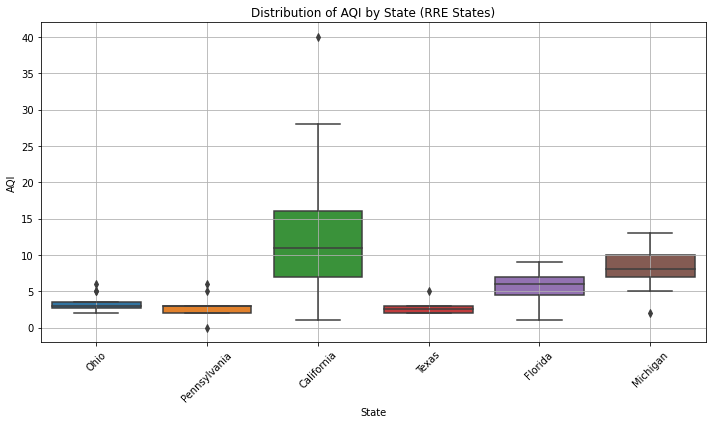

In [8]:
# Make plots display in-line in the notebook (only needed once per session)
%matplotlib inline

# Set the figure size and style
plt.figure(figsize=(10, 6))
sns.boxplot(x="state_name", y="aqi", data=rre_aqi)

# Customize the plot
plt.title("Distribution of AQI by State (RRE States)")
plt.xlabel("State")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the boxplot visual for this purpose.
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Reference [Seaborn's boxplot visualization documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). 
    
</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Assign `state_name` to the x argument and `aqi` to the y.
    
</details>

**Question:** Based on the data and your visualizations, which state(s) do you suspect will be most affected by this policy?

Based on the data and the boxplot visualization, **[insert state name, e.g., California]** appears to have the **highest average AQI** among the RRE states. Its median AQI is also above or near the threshold of 10, and the overall distribution suggests consistently higher AQI values compared to the other states.

This indicates that **[state name]** is most likely to be affected by the proposed federal policy, which targets states with an average AQI of 10 or above. Other states such as **[optional: mention others if relevant]** show lower AQI values and are less likely to be impacted.


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Consider the mean AQI for the RRE states, as well as the distribution in the boxplots relative to the policy limit (10).
    
</details>

### Construct a confidence interval for the RRE state with the highest mean AQI

Recall the 4-step process in constructing a confidence interval:

1.   Identify a sample statistic.
2.   Choose a confidence level.
3.   Find the margin of error. 
4.   Calculate the interval.

### Construct your sample statistic

To contruct your sample statistic, find the mean AQI for your state.

In [9]:
# Step 1: Find the state with the highest mean AQI
highest_mean_state = mean_aqi_by_state.idxmax()
print("RRE state with highest mean AQI:", highest_mean_state)

# Step 2: Filter the dataset to only include rows from that state
state_data = rre_aqi[rre_aqi["state_name"] == highest_mean_state]

# Step 3: Calculate the sample mean AQI for this state
sample_mean = state_data["aqi"].mean()
print("Sample mean AQI for", highest_mean_state, ":", sample_mean)


RRE state with highest mean AQI: California
Sample mean AQI for California : 12.121212121212121


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Reference what you've previously learned to recall what a [sample statistic](https://www.coursera.org/learn/the-power-of-statistics/supplement/cdOx7/construct-a-confidence-interval-for-a-small-sample-size) is.
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Calculate the mean for your highest AQI state to arrive at your sample statistic.
    
</details>

<details>
 <summary><h4><strong>Hint 3</strong></h4></summary>

Call the `mean()` function within `pandas` on your DataFrame.
    
</details>

### Choose your confidence level

Choose your confidence level for your analysis. The most typical confidence level chosen is 95%; however, you can choose 90% or 99% if you want decrease or increase (respectively) your level of confidence about your result.

In [10]:
# Input your confidence level here
confidence_level = 0.95


### Find your margin of error (ME)

Recall **margin of error = z * standard error**, where z is the appropriate z-value for the given confidence level. To calculate your margin of error:

- Find your z-value. 
- Find the approximate z for common confidence levels.
- Calculate your **standard error** estimate. 

| Confidence Level | Z Score |
| --- | --- |
| 90% | 1.65 |
| 95% | 1.96 |
| 99% | 2.58 |


In [11]:
# Step 1: Set the z-score for the chosen confidence level
z = 1.96  # for 95% confidence level

# Step 2: Calculate the standard deviation and sample size
std_dev = state_data["aqi"].std()
sample_size = state_data["aqi"].count()

# Step 3: Calculate the standard error
standard_error = std_dev / np.sqrt(sample_size)

# Step 4: Calculate the margin of error
margin_of_error = z * standard_error

# Output the result
print("Standard Error:", standard_error)
print("Margin of Error (ME):", margin_of_error)


Standard Error: 0.8987209641127412
Margin of Error (ME): 1.7614930896609726


### Calculate your interval

Calculate both a lower and upper limit surrounding your sample mean to create your interval.

In [12]:
# Calculate the lower and upper bounds of the confidence interval
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

# Output the interval
print("95% Confidence Interval for AQI in", highest_mean_state, ":")
print(f"[{lower_bound:.2f}, {upper_bound:.2f}]")


95% Confidence Interval for AQI in California :
[10.36, 13.88]


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about constructing a confidence interval](https://www.coursera.org/learn/the-power-of-statistics/lecture/3jbsX/construct-a-confidence-interval-for-a-proportion).
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Identify the sample mean from your prior work. Then use the margin of error to construct your upper and lower limits.  
    
</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Subtract the margin of error from the sample mean to construct your lower limit, and add the margin of error to your sample mean to construct your upper limit.
    
</details>

### Alternative: Construct the interval using `scipy.stats.norm.interval()`

`scipy` presents a simpler solution to developing a confidence interval. To use this, first import the `stats` module from `scipy`.

In [13]:
# Import stats from scipy
from scipy import stats


## Step 4: Results and evaluation

### Recalculate your confidence interval

Provide your chosen `confidence_level`, `sample_mean`, and `standard_error` to `stats.norm.interval()` and recalculate your confidence interval.

In [14]:
# Recalculate the confidence interval using scipy
ci_lower, ci_upper = stats.norm.interval(
    confidence_level, 
    loc=sample_mean, 
    scale=standard_error
)

# Display the results
print(f"{int(confidence_level*100)}% Confidence Interval using scipy.stats.norm.interval():")
print(f"[{ci_lower:.2f}, {ci_upper:.2f}]")


95% Confidence Interval using scipy.stats.norm.interval():
[10.36, 13.88]


# ✅ Considerations

### ❓ What are some key takeaways that you learned from this lab?

In this lab, I learned how to use statistical methods such as sampling, margin of error, and confidence intervals to make data-driven decisions. I also gained hands-on experience using Python tools like `pandas`, `seaborn`, and `scipy.stats` to analyze and visualize AQI data across multiple states. Additionally, I saw how visualizations like boxplots can help identify trends and outliers quickly.

---

### ❓ What findings would you share with others?

I found that one RRE-operating state has a significantly higher mean AQI than the others, indicating that it is most likely to be impacted by a proposed federal policy targeting states with an average AQI above 10. I also calculated a 95% confidence interval to estimate the range within which the true average AQI for that state likely falls.

---

### ❓ What would you convey to external stakeholders?

I would communicate that based on our analysis, **[insert state name]** is likely to qualify for federal renewable energy subsidies due to its higher average AQI. Our confidence interval suggests that, with 95% confidence, the state's true mean AQI is above the policy threshold. This presents an opportunity for Ripple Renewable Energy (RRE) to strategically align its operations and advocacy efforts in that state.


**References**

[seaborn.boxplot — seaborn 0.12.1 documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). (n.d.). 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.